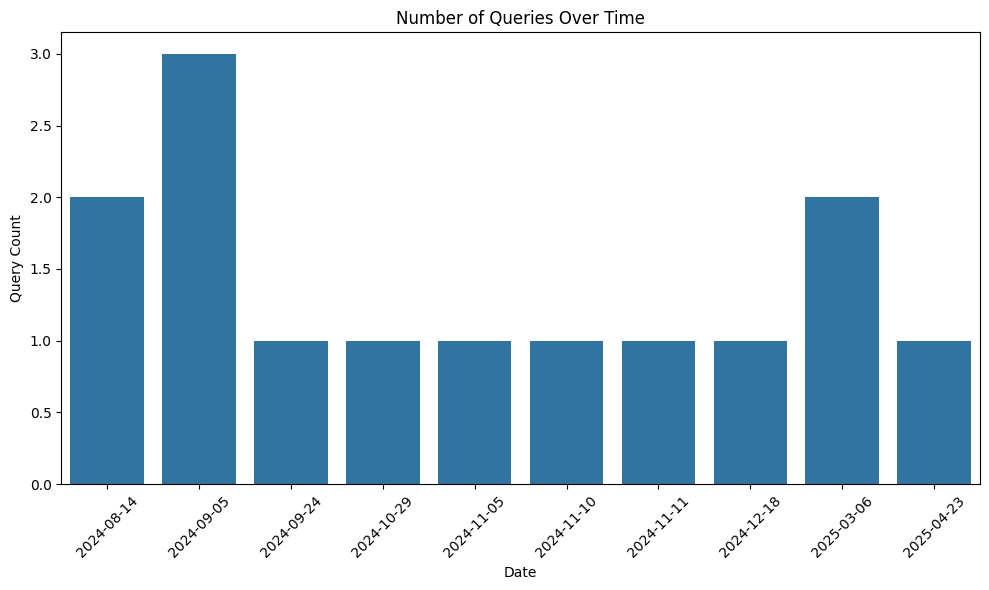

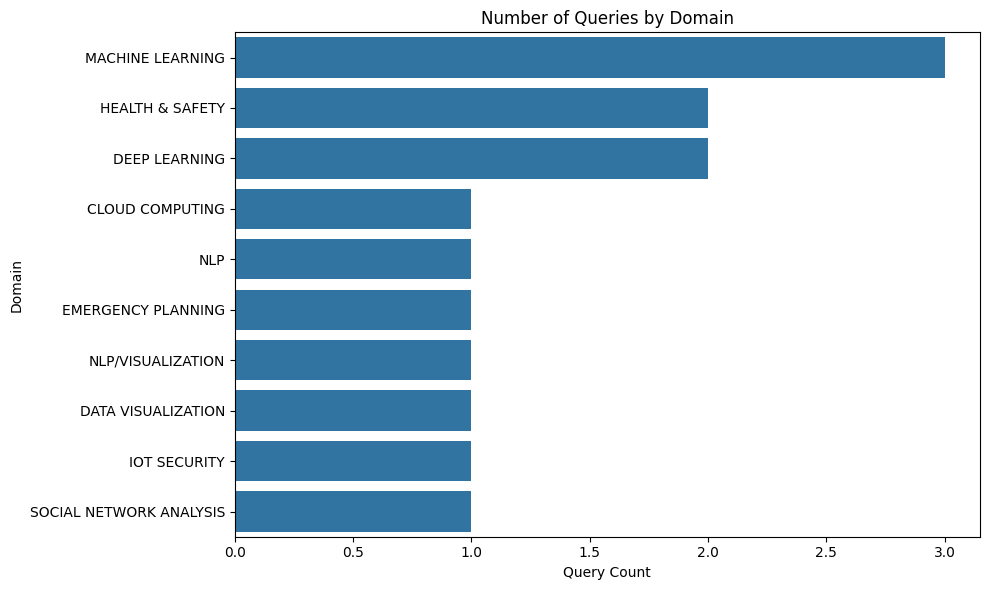

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV
file_path = "/content/drive/MyDrive/ML Project/chatgpt_query_history.csv"
df = pd.read_csv(file_path)

# Convert DateTime to datetime object
df['DateTime'] = pd.to_datetime(df['DateTime'])

# Extract Date and Time separately
df['Date'] = df['DateTime'].dt.date
df['Time'] = df['DateTime'].dt.time

# --- Visualization 1: Queries Over Time ---
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Date', order=sorted(df['Date'].unique()))
plt.xticks(rotation=45)
plt.title("Number of Queries Over Time")
plt.xlabel("Date")
plt.ylabel("Query Count")
plt.tight_layout()
plt.show()

# --- Visualization 2: Queries by Domain ---
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Domain', order=df['Domain'].value_counts().index)
plt.title("Number of Queries by Domain")
plt.xlabel("Query Count")
plt.ylabel("Domain")
plt.tight_layout()
plt.show()


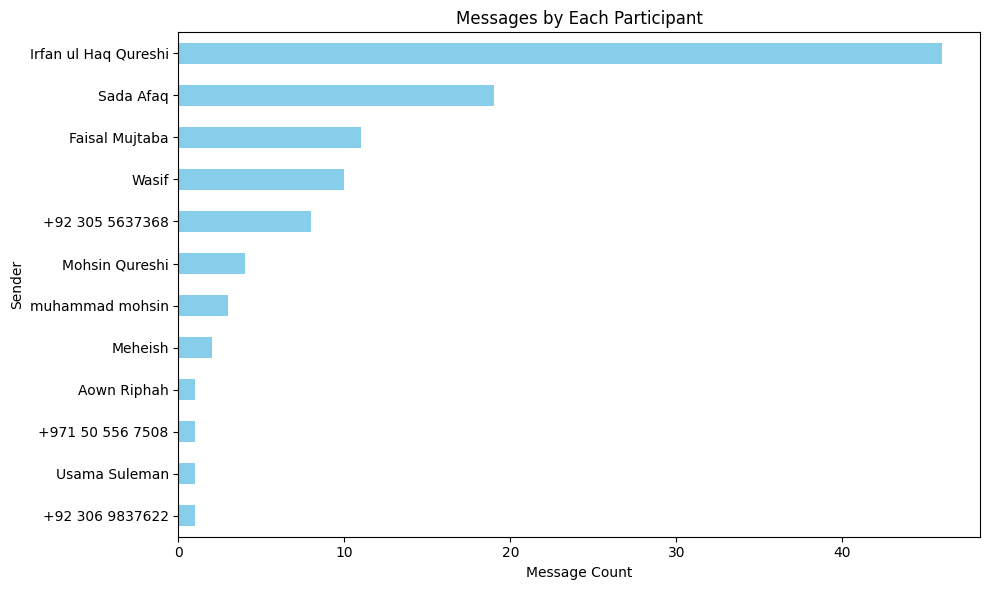

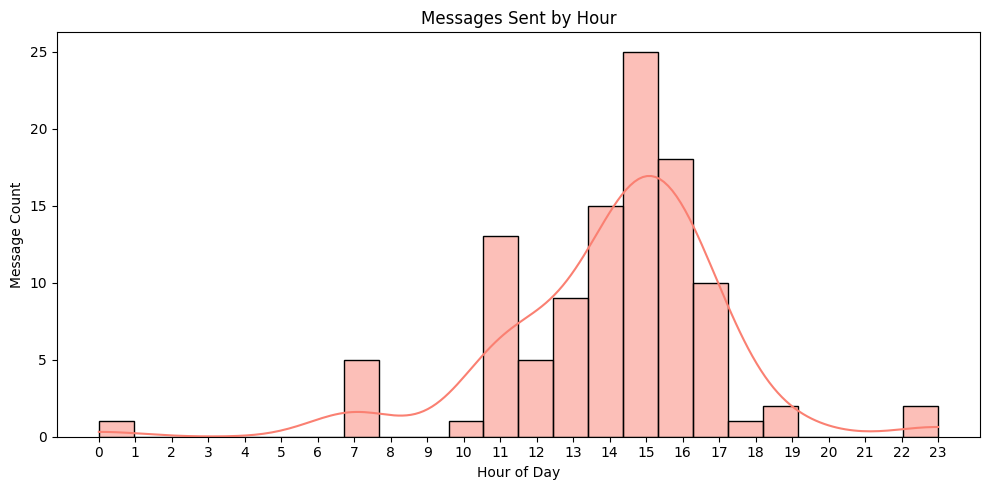

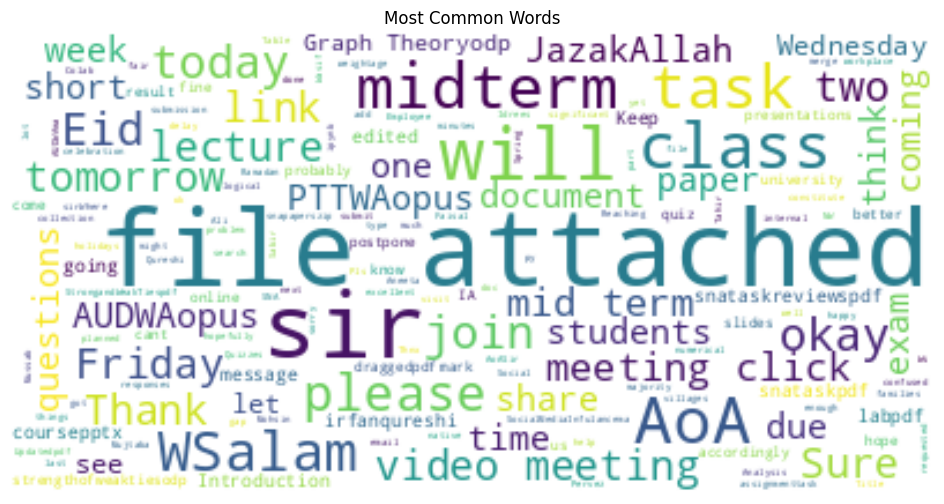

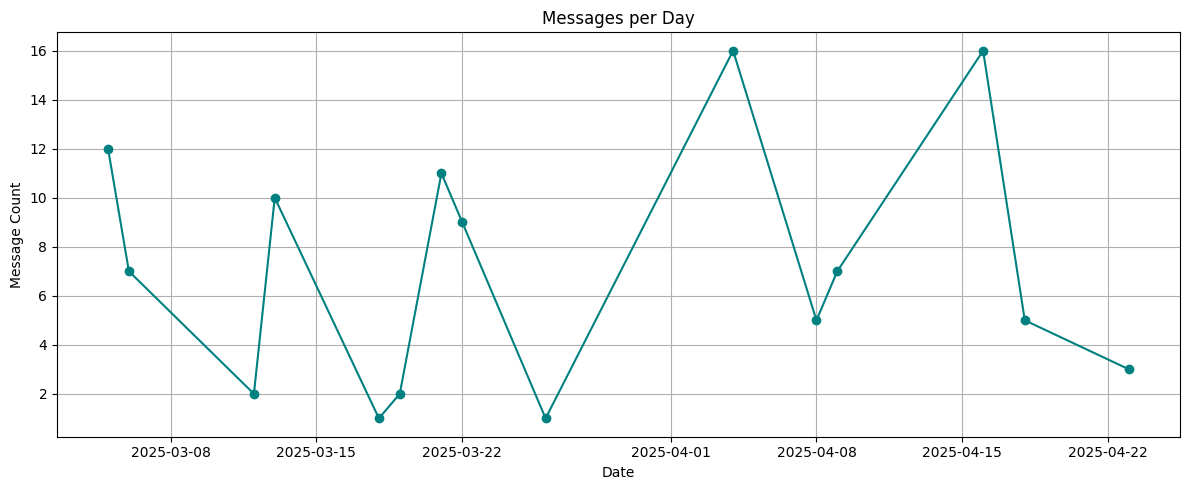

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import re

# Step 1: Load Data
file_path = "/content/drive/MyDrive/ML Project/whatsapp_chat_extracted_v2.csv"
df = pd.read_csv(file_path)

# Step 2: Preprocessing
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
# Changed line: Using %I for 12-hour format and %p for AM/PM indicator
df['DateTime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'], format='%Y-%m-%d %I:%M %p')
df['Sender'] = df['Sender'].str.strip()
df['Message'] = df['Message'].fillna('')

# Remove system messages
system_keywords = ['added', 'removed', 'created group', 'left', 'changed', 'deleted']
df = df[~df['Message'].str.contains('|'.join(system_keywords), case=False)]

# Step 3: Analysis
df['Hour'] = df['DateTime'].dt.hour
df['DateOnly'] = df['DateTime'].dt.date

# Top senders
top_senders = df['Sender'].value_counts()

# WordCloud text
all_messages = ' '.join(df['Message'].dropna())
cleaned_text = re.sub(r"http\S+|@\S+|[^A-Za-z\s]", '', all_messages)

# Step 4: Visualizations

## 4.1 Messages per Sender
plt.figure(figsize=(10, 6))
top_senders.plot(kind='barh', color='skyblue')
plt.title("Messages by Each Participant")
plt.xlabel("Message Count")
plt.ylabel("Sender")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 4.2 Activity by Hour
plt.figure(figsize=(10, 5))
sns.histplot(df['Hour'], bins=24, kde=True, color="salmon")
plt.title("Messages Sent by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Message Count")
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

## 4.3 Word Cloud
wordcloud = WordCloud(stopwords=STOPWORDS, background_color='white', max_words=200).generate(cleaned_text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Most Common Words")
plt.show()

## 4.4 Daily Message Volume
daily_counts = df.groupby('DateOnly').size()
plt.figure(figsize=(12, 5))
daily_counts.plot(kind='line', marker='o', color='teal')
plt.title("Messages per Day")
plt.xlabel("Date")
plt.ylabel("Message Count")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from collections import Counter
import re

# Load data
file_path = "/content/drive/MyDrive/ML Project/whatsapp_chat_extracted_v2.csv"
df = pd.read_csv(file_path)

# Preprocessing
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
# Updated line to use %I for 12-hour format and %p for AM/PM
df['DateTime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'], format='%Y-%m-%d %I:%M %p')
df['Sender'] = df['Sender'].str.strip()
df['Message'] = df['Message'].fillna('')
df = df[~df['Message'].str.contains('added|removed|created group|left|changed|deleted', case=False)]

# Feature engineering
df['Hour'] = df['DateTime'].dt.hour
df['DateOnly'] = df['DateTime'].dt.date

# --- 📋 Data Tables ---

## 1. Top Participants
top_senders_df = df['Sender'].value_counts().reset_index()
top_senders_df.columns = ['Sender', 'Message Count']
print("📋 Top Participants:")
print(top_senders_df)

## 2. Messages by Hour
hourly_df = df.groupby('Hour').size().reset_index(name='Message Count')
print("\n🕒 Message Distribution by Hour:")
print(hourly_df)

## 3. Messages by Date
daily_df = df.groupby('DateOnly').size().reset_index(name='Message Count')
print("\n📅 Daily Message Activity:")
print(daily_df)

## 4. Most Common Words
all_messages = ' '.join(df['Message'])
cleaned_text = re.sub(r"http\S+|@\S+|[^A-Za-z\s]", '', all_messages)
words = cleaned_text.lower().split()
filtered_words = [word for word in words if word not in STOPWORDS and len(word) > 2]
word_freq = Counter(filtered_words)
common_words_df = pd.DataFrame(word_freq.most_common(10), columns=["Word", "Frequency"])
print("\n📝 Top 10 Most Common Words (excluding stopwords):")
print(common_words_df)

# You can also visualize these tables in a notebook using `display()` if running in Jupyter.


📋 Top Participants:
                  Sender  Message Count
0   Irfan ul Haq Qureshi             46
1              Sada Afaq             19
2         Faisal Mujtaba             11
3                  Wasif             10
4        +92 305 5637368              8
5         Mohsin Qureshi              4
6        muhammad mohsin              3
7                Meheish              2
8            Aown Riphah              1
9       +971 50 556 7508              1
10         Usama Suleman              1
11       +92 306 9837622              1

🕒 Message Distribution by Hour:
    Hour  Message Count
0      0              1
1      7              5
2     10              1
3     11             13
4     12              5
5     13              9
6     14             15
7     15             25
8     16             18
9     17             10
10    18              1
11    19              2
12    23              2

📅 Daily Message Activity:
      DateOnly  Message Count
0   2025-03-05             12
1   

<ipython-input-2-76f601e7ad96>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Hour'] = df['DateTime'].dt.hour
<ipython-input-2-76f601e7ad96>:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['DateOnly'] = df['DateTime'].dt.date
